# Imports

In [1]:
from pySVA.sva_core import *
from pySVA.sva_calc import *

In [2]:
from pySVA.sva_helpers import *

In [3]:
import dfm_tools as dfmt
import numpy as np
import xarray as xr

# Data description

In [4]:
# data_description = {
#     "nfaces": "mesh2d_nFaces",
#     "depth": "mesh2d_nLayers",
#     "time" : "time"
# }

data_description = {
    "flow_area": "mesh2d_au",
    "volume": "mesh2d_vol1",
    "velx" : "mesh2d_ucx",
    "vely" : "mesh2d_ucy",
    "velz" : "mesh2d_ucz",
    "viscosity" : "mesh2d_vicwwu",
    "tracer" : "mesh2d_sa1",
    "depth": "mesh2d_flowelem_zcc",
    "interfaces": "mesh2d_flowelem_zw"
}

In [5]:
import numpy as np

# Set up dask cluster

In [6]:
from dask_jobqueue import SLURMCluster
from dask.distributed import Client

In [7]:
n_cores = 16
n_processes = 4
n_workers = n_cores/n_processes
mem_lim = str(336)+'GB' # str(int(np.floor(336/(n_workers))))+'GB' # 336 for genoa # 224 for rome #n_cores*

In [8]:
cluster = SLURMCluster(name='dask-cluster',
                       cores=n_cores,
                       memory=mem_lim,
                       processes=n_processes,
                       interface='ib0',
                       queue='genoa',
                       walltime='04:00:00',
                       asynchronous=0)

INFO:distributed.scheduler:State start
INFO:distributed.diskutils:Found stale lock file and directory '/scratch-local/mgeraeds/dask-scratch-space/scheduler-4x8w7em0', purging
INFO:distributed.scheduler:  Scheduler at: tcp://172.22.63.190:40661
INFO:distributed.scheduler:  dashboard at:  http://172.22.63.190:8787/status
INFO:distributed.scheduler:Registering Worker plugin shuffle


In [9]:
print(cluster.job_script())

#!/usr/bin/env bash

#SBATCH -J dask-worker
#SBATCH -p genoa
#SBATCH -n 1
#SBATCH --cpus-per-task=16
#SBATCH --mem=313G
#SBATCH -t 04:00:00

/home/mgeraeds/.conda/envs/dfm_proc_env/bin/python -m distributed.cli.dask_worker tcp://172.22.63.190:40661 --name dummy-name --nthreads 4 --memory-limit 78.23GiB --nworkers 4 --nanny --death-timeout 60 --interface ib0



In [10]:
cluster.scale(1)

In [11]:
client = Client(cluster)

INFO:distributed.scheduler:Receive client connection: Client-3a0f71d3-0190-11ef-87a4-00001029fe80
INFO:distributed.core:Starting established connection to tcp://172.22.63.190:38288


In [12]:
client

Connection method: Cluster object,Cluster type: dask_jobqueue.SLURMCluster
Dashboard: http://172.22.63.190:8787/status,
Dashboard: http://172.22.63.190:8787/status,Workers: 0
Total threads: 0,Total memory: 0 B
Comm: tcp://172.22.63.190:40661,Workers: 0
Dashboard: http://172.22.63.190:8787/status,Total threads: 0
Started: Just now,Total memory: 0 B


In [13]:
# file_nc = r'/projects/0/einf1300/saltis-wp3-1/C_Work/00_RMM3d_2022_simulations/computations/B02_2022_jul21-aug7/B02_2022_jul21-aug7_sm/RMM_dflowfm_2022_jul21_aug7_sm_000*_map.nc'

# Load dataset

In [14]:
file_nc = r'/projects/0/einf1300/saltis-wp3-1/C_Work/04_RMD_2022/computations/B04/B04_2022_jun23-24/ZUNO-zd_dflowfm_B04_jun23-24_0000_map.nc'

In [15]:
data_xr = dfmt.open_partitioned_dataset(file_nc.replace('_0000_',"_*_"), chunks={'time':1})# "mesh2d_nFaces":50000, "mesh2d_nNodes":50000, "mesh2d_nEdges":50000})#, "mesh2d_nFaces":5000, "mesh2d_nNodes":5000, "mesh2d_nEdges":5000})

>> xu.open_dataset() with 96 partition(s): 1 

INFO:distributed.scheduler:Register worker <WorkerState 'tcp://172.22.60.39:34219', name: dask-cluster-0-2, status: init, memory: 0, processing: 0>
INFO:distributed.scheduler:Starting worker compute stream, tcp://172.22.60.39:34219
INFO:distributed.core:Starting established connection to tcp://172.22.60.39:46078
INFO:distributed.scheduler:Register worker <WorkerState 'tcp://172.22.60.39:35907', name: dask-cluster-0-3, status: init, memory: 0, processing: 0>
INFO:distributed.scheduler:Starting worker compute stream, tcp://172.22.60.39:35907
INFO:distributed.core:Starting established connection to tcp://172.22.60.39:46094
INFO:distributed.scheduler:Register worker <WorkerState 'tcp://172.22.60.39:39475', name: dask-cluster-0-0, status: init, memory: 0, processing: 0>
INFO:distributed.scheduler:Starting worker compute stream, tcp://172.22.60.39:39475
INFO:distributed.core:Starting established connection to tcp://172.22.60.39:46064
INFO:distributed.scheduler:Register worker <WorkerState 't

2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47 48 49 50 51 52 53 54 55 56 57 58 59 60 61 62 63 64 65 66 67 68 69 70 71 72 73 74 75 76 77 78 79 80 81 82 83 84 85 86 87 88 89 90 91 92 93 94 95 96 : 119.05 sec
>> xu.merge_partitions() with 96 partition(s): 11.09 sec
>> some variables dropped with merging of partitions: ['mesh2d_face_x_bnd', 'mesh2d_face_y_bnd']
>> dfmt.open_partitioned_dataset() total: 130.26 sec


In [16]:
uds = data_xr

In [17]:
uds.ugrid.set_crs("EPSG:28992")
uds = uds.ugrid.to_crs('WGS84')

In [18]:
gridname = uds.grid.name

In [19]:
uds.ugrid.crs[f'{gridname}'].name == 'WGS 84'

True

In [20]:
uds['mesh2d_sa1'] = uds['mesh2d_sa1'].where(uds['mesh2d_flowelem_bl'] < 0, np.nan)

In [21]:
uds['mesh2d_sa1'] = uds['mesh2d_sa1'].where(uds['mesh2d_sa1'] < 35, np.nan)


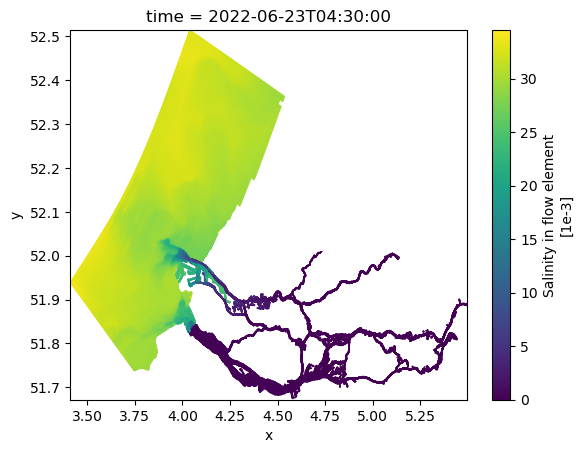

In [22]:
uds['mesh2d_sa1'].isel(time=5, mesh2d_nLayers=45).ugrid.plot()

In [23]:
import xugrid as xu
import matplotlib.pyplot as plt

In [24]:
sva_obj = constructorSVA(uds, data_description)

In [25]:
gradient = sva_obj.compute_gradient_on_face(sva_obj.tracer)

/home/mgeraeds/.conda/envs/dfm_proc_env/lib/python3.9/site-packages/xarray/core/dataset.py:5557: PerformanceWarning: Reshaping is producing a large chunk. To accept the large
chunk and silence this warning, set the option
    >>> with dask.config.set(**{'array.slicing.split_large_chunks': False}):
    ...     array.reshape(shape)

To avoid creating the large chunks, set the option
    >>> with dask.config.set(**{'array.slicing.split_large_chunks': True}):
    ...     array.reshape(shape)Explictly passing ``limit`` to ``reshape`` will also silence this warning
    >>> array.reshape(shape, limit='128 MiB')
  result = result._unstack_full_reindex(
/home/mgeraeds/.conda/envs/dfm_proc_env/lib/python3.9/site-packages/xarray/core/dataset.py:5557: PerformanceWarning: Reshaping is producing a large chunk. To accept the large
chunk and silence this warning, set the option
    >>> with dask.config.set(**{'array.slicing.split_large_chunks': False}):
    ...     array.reshape(shape)

To avoid creat

In [26]:
from dfmproc.utils.plotting import GeneralPlot, plot_basic_background

/gpfs/home2/mgeraeds/Repositories/cmestuary/cmestuary/cm.py:36: MatplotlibDeprecationWarning: The register_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps.register(name)`` instead.
  cm.register_cmap(cmap = reg_map)
/gpfs/home2/mgeraeds/Repositories/cmestuary/cmestuary/cm.py:40: MatplotlibDeprecationWarning: The register_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps.register(name)`` instead.
  cm.register_cmap(cmap = reg_map_r)
/gpfs/home2/mgeraeds/Repositories/cmestuary/cmestuary/cm.py:36: MatplotlibDeprecationWarning: The register_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps.register(name)`` instead.
  cm.register_cmap(cmap = reg_map)
/gpfs/home2/mgeraeds/Repositories/cmestuary/cmestuary/cm.py:40: MatplotlibDeprecationWarning: The register_cmap function was deprecate

In [27]:
import cmocean.cm as cmo
import cmestuary.cm as cme

In [28]:
dimn_cart = f'mesh2d_nCartesian_coords'

In [29]:
bool_drycells = (uds['mesh2d_s1'] - uds['mesh2d_flowelem_bl']) < 0.25 # 0.0001 # standard EPSHU #other option: 0.0025
# bool_drycells = (uds['mesh2d_flowelem_bl'] > 0)

In [30]:
salinity_gradient = np.sqrt(gradient.isel({dimn_cart:0})**2 + gradient.isel({dimn_cart:1})**2).where(~bool_drycells)

In [32]:
t = '2022/06/23 02:30'

/home/mgeraeds/.conda/envs/dfm_proc_env/lib/python3.9/site-packages/distributed/client.py:3163: UserWarning: Sending large graph of size 39.34 MiB.
This may cause some slowdown.
Consider scattering data ahead of time and using futures.
  warnings.warn(


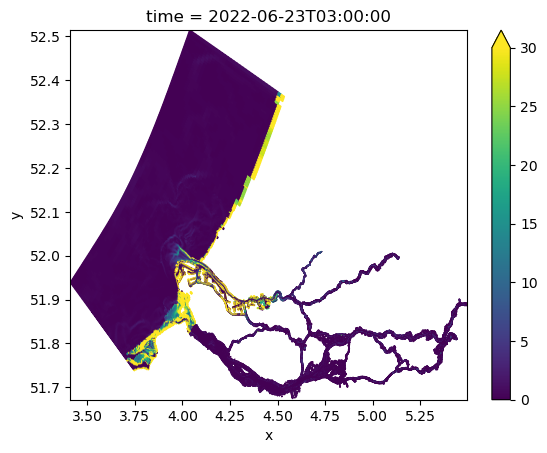

In [42]:
(salinity_gradient*1000).isel(mesh2d_nLayers=45).isel(time=2).ugrid.plot(vmin=0, vmax=30)

In [44]:
ucx_grad = sva_obj.compute_gradient_on_face(sva_obj.velx)
ucy_grad = sva_obj.compute_gradient_on_face(sva_obj.vely)

/home/mgeraeds/.conda/envs/dfm_proc_env/lib/python3.9/site-packages/xarray/core/dataset.py:5557: PerformanceWarning: Reshaping is producing a large chunk. To accept the large
chunk and silence this warning, set the option
    >>> with dask.config.set(**{'array.slicing.split_large_chunks': False}):
    ...     array.reshape(shape)

To avoid creating the large chunks, set the option
    >>> with dask.config.set(**{'array.slicing.split_large_chunks': True}):
    ...     array.reshape(shape)Explictly passing ``limit`` to ``reshape`` will also silence this warning
    >>> array.reshape(shape, limit='128 MiB')
  result = result._unstack_full_reindex(
/home/mgeraeds/.conda/envs/dfm_proc_env/lib/python3.9/site-packages/xarray/core/dataset.py:5557: PerformanceWarning: Reshaping is producing a large chunk. To accept the large
chunk and silence this warning, set the option
    >>> with dask.config.set(**{'array.slicing.split_large_chunks': False}):
    ...     array.reshape(shape)

To avoid creat

In [36]:
hex_list = ['#2d0046', '#30024a', '#32044e', '#340752', '#370a56', '#390d5a', '#3c105d', '#3e1361', '#411664', '#431968', '#461d6b', '#48206f', '#4b2372', '#4d2675', '#502978', '#522c7b', '#542f7e', '#573381', '#593684', '#5c3987', '#5e3c89', '#60408c', '#62438e', '#654691', '#674a93', '#694d96', '#6b5098', '#6e549a', '#70579d', '#725b9f', '#745ea1', '#7662a3', '#7865a5', '#7a69a7', '#7c6ca9', '#7e70ab', '#8174ac', '#8377af', '#867ab1', '#897db3', '#8c81b5', '#8f84b7', '#9287ba', '#958abc', '#988ebe', '#9b91c0', '#9e94c2', '#a198c4', '#a49bc7', '#a79ec9', '#aaa2cb', '#ada5cd', '#b0a9cf', '#b4acd1', '#b7afd3', '#bab3d6', '#bdb6d8', '#c0bada', '#c3bddc', '#c6c1de', '#c9c4e0', '#ccc8e2', '#cfcbe4', '#d2cfe6', '#d5d2e8', '#d9d6ea', '#dcdaed', '#dfddef', '#e2e1f1', '#e5e4f3', '#e8e8f5', '#ebebf7', '#efeff9', '#f2f3fb', '#f5f6fd', '#f9fdfc', '#f3fbf9', '#edf9f6', '#e7f7f4', '#e1f4f1', '#dbf2ee', '#d5f0eb', '#d0eee8', '#caebe6', '#c5e9e3', '#c0e7e0', '#bae4dd', '#b5e2da', '#b0dfd8', '#abddd5', '#a6dad2', '#a1d8cf', '#9cd5cd', '#97d3ca', '#93d0c7', '#8ecec5', '#89cbc2', '#85c8bf', '#80c6bd', '#7cc3ba', '#77c1b7', '#73beb5', '#6ebbb2', '#6ab9af', '#66b6ad', '#62b4aa', '#5db1a8', '#59aea5', '#55aca2', '#51a9a0', '#4da69d', '#49a39b', '#44a198', '#409e96', '#3c9b93', '#389991', '#34968e', '#32938b', '#309088', '#2d8e86', '#2b8b83', '#298880', '#27857d', '#24837a', '#228077', '#207d74', '#1e7a72', '#1c786f', '#1a756c', '#187269', '#166f66', '#146d63', '#126a60', '#10675e', '#0e655b', '#0c6258', '#0b5f55', '#095d52', '#075a4f', '#06574c', '#05554a', '#045247', '#035044', '#024d41', '#024b3e', '#01483b', '#014639', '#004336', '#004033', '#003e30']

In [35]:
from cmestuary.tools import write_hex_to_rgb_txt

In [37]:
write_hex_to_rgb_txt(hex_list, 'variance', r'/home/mgeraeds/Repositories/cmestuary/cmestuary/rgb')

In [46]:
div = ucy_grad.isel(mesh2d_nCartesian_coords=1) + ucx_grad.isel(mesh2d_nCartesian_coords=0)

In [48]:
f = 2 * 7.2921E-5 * np.sin(51.92651)

/home/mgeraeds/.conda/envs/dfm_proc_env/lib/python3.9/site-packages/distributed/client.py:3163: UserWarning: Sending large graph of size 47.08 MiB.
This may cause some slowdown.
Consider scattering data ahead of time and using futures.
  warnings.warn(


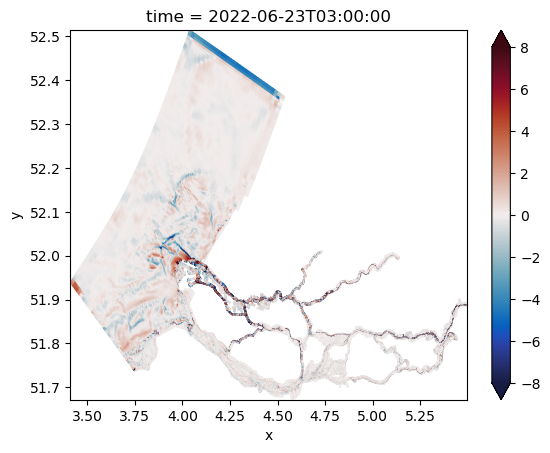

In [52]:
(div/f).isel(mesh2d_nLayers=45).isel(time=2).ugrid.plot(vmin=-8, vmax=8, cmap=cmo.balance)

In [31]:
straining = sva_obj.straining

/home/mgeraeds/.conda/envs/dfm_proc_env/lib/python3.9/site-packages/xarray/core/dataset.py:5557: PerformanceWarning: Reshaping is producing a large chunk. To accept the large
chunk and silence this warning, set the option
    >>> with dask.config.set(**{'array.slicing.split_large_chunks': False}):
    ...     array.reshape(shape)

To avoid creating the large chunks, set the option
    >>> with dask.config.set(**{'array.slicing.split_large_chunks': True}):
    ...     array.reshape(shape)Explictly passing ``limit`` to ``reshape`` will also silence this warning
    >>> array.reshape(shape, limit='128 MiB')
  result = result._unstack_full_reindex(
/home/mgeraeds/.conda/envs/dfm_proc_env/lib/python3.9/site-packages/xarray/core/dataset.py:5557: PerformanceWarning: Reshaping is producing a large chunk. To accept the large
chunk and silence this warning, set the option
    >>> with dask.config.set(**{'array.slicing.split_large_chunks': False}):
    ...     array.reshape(shape)

To avoid creat

In [35]:
fig, ax = plt.subplots(FigureClass=GeneralPlot, figsize=(6,5))
bg = plot_basic_background(ax=ax, crs='WGS84', zorder=0)
pc = straining.isel(time=2).ugrid.plot(vmin=-0.005, vmax=0.005, cmap=cme.variance, add_labels=False, add_colorbar=False)
# pc=(div).isel(time=20, mesh2d_nLayers=45).ugrid.sel(x=slice(45_000, 85_000), y=slice(450_000, 480_000)).ugrid.plot(extend='both', cmap=cmo.balance, zorder=1, add_labels=False, add_colorbar=False)

# add colorbar
cax = fig.add_axes([ax.get_position().x1 + 0.01, ax.get_position().y0 + 0.02, 0.015, ax.get_position().height - 0.2])
cax.tick_params(axis=u'both', which=u'both', length=0)

# cbar limits + others
cb = plt.colorbar(pc, cax=cax, extend='both')
# tracer_string = r"straining, $\int -2u'_v s_'v \cdot \nabla \bar{s} dz$ [psu$^2$m$^{-1}$]"
cb.set_label(f'{tracer_string}', labelpad=10)
# cb.ax.tick_params(labelsize=9) 

/home/mgeraeds/.conda/envs/dfm_proc_env/lib/python3.9/site-packages/geopandas/geodataframe.py:1640: DeprecationWarning: Passing a SingleBlockManager to Series is deprecated and will raise in a future version. Use public APIs instead.
  srs = pd.Series(*args, **kwargs)
/home/mgeraeds/.conda/envs/dfm_proc_env/lib/python3.9/site-packages/geopandas/geodataframe.py:1640: DeprecationWarning: Passing a SingleBlockManager to Series is deprecated and will raise in a future version. Use public APIs instead.
  srs = pd.Series(*args, **kwargs)
/home/mgeraeds/.conda/envs/dfm_proc_env/lib/python3.9/site-packages/pandas/core/frame.py:706: DeprecationWarning: Passing a BlockManager to GeoDataFrame is deprecated and will raise in a future version. Use public APIs instead.
  warnings.warn(
/home/mgeraeds/.conda/envs/dfm_proc_env/lib/python3.9/site-packages/geopandas/geodataframe.py:1640: DeprecationWarning: Passing a SingleBlockManager to Series is deprecated and will raise in a future version. Use publ

Error in callback <function _draw_all_if_interactive at 0x1536137b3550> (for post_execute):


RuntimeError: latex was not able to process the following string:
b"straining, $\\\\int -2u'_v s_'v \\\\cdot \\\\nabla \\\\bar{s}dz$ [psu$^2$m$^{-1}$]"

Here is the full command invocation and its output:

latex -interaction=nonstopmode --halt-on-error --output-directory=tmp0einjflz 4988d1b2eca2b197bea7abde1615f5c3.tex

This is pdfTeX, Version 3.14159265-2.6-1.40.19 (TeX Live 2018) (preloaded format=latex)
 restricted \write18 enabled.
entering extended mode
(./4988d1b2eca2b197bea7abde1615f5c3.tex
LaTeX2e <2017-04-15>
Babel <3.17> and hyphenation patterns for 3 language(s) loaded.
(/usr/share/texlive/texmf-dist/tex/latex/base/article.cls
Document Class: article 2014/09/29 v1.4h Standard LaTeX document class
(/usr/share/texlive/texmf-dist/tex/latex/base/size10.clo))
(/usr/share/texlive/texmf-dist/tex/latex/type1cm/type1cm.sty)
(/usr/share/texlive/texmf-dist/tex/latex/cm-super/type1ec.sty
(/usr/share/texlive/texmf-dist/tex/latex/base/t1cmr.fd))
(/usr/share/texlive/texmf-dist/tex/latex/ba

RuntimeError: latex was not able to process the following string:
b"straining, $\\\\int -2u'_v s_'v \\\\cdot \\\\nabla \\\\bar{s}dz$ [psu$^2$m$^{-1}$]"

Here is the full command invocation and its output:

latex -interaction=nonstopmode --halt-on-error --output-directory=tmpmmag56_j 4988d1b2eca2b197bea7abde1615f5c3.tex

This is pdfTeX, Version 3.14159265-2.6-1.40.19 (TeX Live 2018) (preloaded format=latex)
 restricted \write18 enabled.
entering extended mode
(./4988d1b2eca2b197bea7abde1615f5c3.tex
LaTeX2e <2017-04-15>
Babel <3.17> and hyphenation patterns for 3 language(s) loaded.
(/usr/share/texlive/texmf-dist/tex/latex/base/article.cls
Document Class: article 2014/09/29 v1.4h Standard LaTeX document class
(/usr/share/texlive/texmf-dist/tex/latex/base/size10.clo))
(/usr/share/texlive/texmf-dist/tex/latex/type1cm/type1cm.sty)
(/usr/share/texlive/texmf-dist/tex/latex/cm-super/type1ec.sty
(/usr/share/texlive/texmf-dist/tex/latex/base/t1cmr.fd))
(/usr/share/texlive/texmf-dist/tex/latex/ba

<GeneralPlot size 600x500 with 2 Axes>

In [39]:
dissipation = sva_obj.dissipation

edge-to-face interpolation: 

/home/mgeraeds/.conda/envs/dfm_proc_env/lib/python3.9/site-packages/xarray/core/dataset.py:5557: PerformanceWarning: Reshaping is producing a large chunk. To accept the large
chunk and silence this warning, set the option
    >>> with dask.config.set(**{'array.slicing.split_large_chunks': False}):
    ...     array.reshape(shape)

To avoid creating the large chunks, set the option
    >>> with dask.config.set(**{'array.slicing.split_large_chunks': True}):
    ...     array.reshape(shape)Explictly passing ``limit`` to ``reshape`` will also silence this warning
    >>> array.reshape(shape, limit='128 MiB')
  result = result._unstack_full_reindex(


0.36 sec


In [31]:
advection = sva_obj.advection

/home/mgeraeds/.conda/envs/dfm_proc_env/lib/python3.9/site-packages/xarray/core/dataset.py:5557: PerformanceWarning: Reshaping is producing a large chunk. To accept the large
chunk and silence this warning, set the option
    >>> with dask.config.set(**{'array.slicing.split_large_chunks': False}):
    ...     array.reshape(shape)

To avoid creating the large chunks, set the option
    >>> with dask.config.set(**{'array.slicing.split_large_chunks': True}):
    ...     array.reshape(shape)Explictly passing ``limit`` to ``reshape`` will also silence this warning
    >>> array.reshape(shape, limit='128 MiB')
  result = result._unstack_full_reindex(
/home/mgeraeds/.conda/envs/dfm_proc_env/lib/python3.9/site-packages/xarray/core/dataset.py:5557: PerformanceWarning: Reshaping is producing a large chunk. To accept the large
chunk and silence this warning, set the option
    >>> with dask.config.set(**{'array.slicing.split_large_chunks': False}):
    ...     array.reshape(shape)

To avoid creat

In [32]:
advection

<xarray.DataArray 'mesh2d_mesh2d_sa1_advection' (time: 45, mesh2d_nFaces: 126438)>
dask.array<sum-aggregate, shape=(45, 126438), dtype=float64, chunksize=(1, 1318), chunktype=numpy.ndarray>
Coordinates:
  * time           (time) datetime64[ns] 2022-06-23 ... 2022-06-24
    mesh2d_face_x  (mesh2d_nFaces) float64 dask.array<chunksize=(1315,), meta=np.ndarray>
    mesh2d_face_y  (mesh2d_nFaces) float64 dask.array<chunksize=(1315,), meta=np.ndarray>
  * mesh2d_nFaces  (mesh2d_nFaces) int64 0 1 2 3 ... 126434 126435 126436 126437

INFO:distributed.core:Event loop was unresponsive in Scheduler for 6.49s.  This is often caused by long-running GIL-holding functions or moving large chunks of data. This can cause timeouts and instability.
INFO:distributed.core:Event loop was unresponsive in Scheduler for 3.02s.  This is often caused by long-running GIL-holding functions or moving large chunks of data. This can cause timeouts and instability.
INFO:distributed.core:Event loop was unresponsive in Scheduler for 7.39s.  This is often caused by long-running GIL-holding functions or moving large chunks of data. This can cause timeouts and instability.


/home/mgeraeds/.conda/envs/dfm_proc_env/lib/python3.9/site-packages/distributed/client.py:3163: UserWarning: Sending large graph of size 49.24 MiB.
This may cause some slowdown.
Consider scattering data ahead of time and using futures.
  warnings.warn(


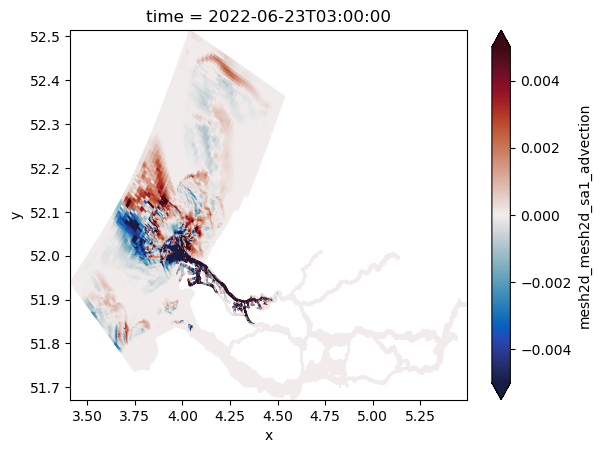

INFO:distributed.core:Event loop was unresponsive in Scheduler for 5.69s.  This is often caused by long-running GIL-holding functions or moving large chunks of data. This can cause timeouts and instability.
INFO:distributed.core:Event loop was unresponsive in Scheduler for 8.31s.  This is often caused by long-running GIL-holding functions or moving large chunks of data. This can cause timeouts and instability.
INFO:distributed.core:Event loop was unresponsive in Scheduler for 4.10s.  This is often caused by long-running GIL-holding functions or moving large chunks of data. This can cause timeouts and instability.
INFO:distributed.core:Event loop was unresponsive in Scheduler for 5.69s.  This is often caused by long-running GIL-holding functions or moving large chunks of data. This can cause timeouts and instability.


In [33]:
advection.isel(time=2).ugrid.plot(vmax=0.005, vmin=-0.005, cmap=cmo.balance)

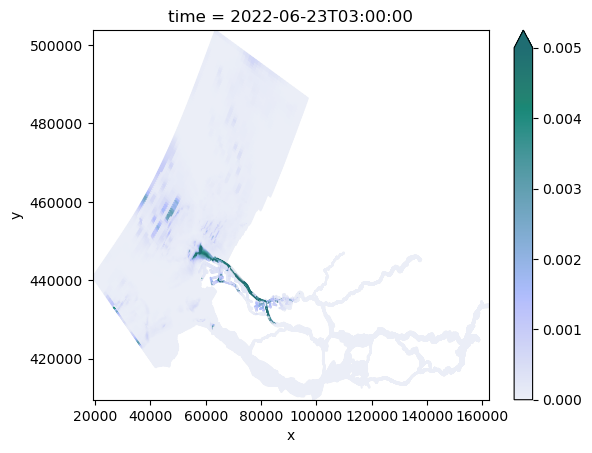

In [45]:
dissipation.isel(time=2).ugrid.plot(vmin=0, vmax=0.005, cmap=cme.variance)

In [37]:
# t = '2022/06/23 02:30'
# fig, ax = plt.subplots(FigureClass=GeneralPlot, figsize=(4,3))
# bg = plot_basic_background(ax=ax, crs='WGS84', zorder=1)
# pc = (salinity_gradient*1000).isel(mesh2d_nLayers=45).sel(time=t).ugrid.sel(y=slice(51.8, 52.4), x=slice(3.6, 4.5)).ugrid.plot(ax=ax,add_labels=False, add_colorbar=False, vmax=5, zorder=0)

# # add colorbar
# cax = fig.add_axes([ax.get_position().x1 + 0.01, ax.get_position().y0 + 0.02, 0.03, ax.get_position().height - 0.2])
# cax.tick_params(axis=u'both', which=u'both', length=0)

# # cbar limits + others
# ax.set_ylim(51.8, 52.35)
# ax.set_xlim(3.65, 4.45)
# cb = plt.colorbar(pc, cax=cax, extend='max')
# tracer_string = r'$|\nabla_h s|$ [psu/km]'
# cb.set_label(f'{tracer_string}', labelpad=10, fontsize=8)
# cb.ax.tick_params(labelsize=6) 
# ax.set_title(f'{t}, LW')
# # plt.savefig('fronts_LW.png', transparent=True)

In [37]:
div = compute_divergence_on_face(sva_obj, sva_obj.velu1)

Unit normal vectors on edges already present Dataset in variable mesh2d_unvs.


/home/mgeraeds/.conda/envs/dfm_proc_env/lib/python3.9/site-packages/xarray/core/dataset.py:5557: PerformanceWarning: Reshaping is producing a large chunk. To accept the large
chunk and silence this warning, set the option
    >>> with dask.config.set(**{'array.slicing.split_large_chunks': False}):
    ...     array.reshape(shape)

To avoid creating the large chunks, set the option
    >>> with dask.config.set(**{'array.slicing.split_large_chunks': True}):
    ...     array.reshape(shape)Explictly passing ``limit`` to ``reshape`` will also silence this warning
    >>> array.reshape(shape, limit='128 MiB')
  result = result._unstack_full_reindex(
/home/mgeraeds/.conda/envs/dfm_proc_env/lib/python3.9/site-packages/distributed/client.py:3163: UserWarning: Sending large graph of size 13.69 MiB.
This may cause some slowdown.
Consider scattering data ahead of time and using futures.
  warnings.warn(
/home/mgeraeds/.conda/envs/dfm_proc_env/lib/python3.9/site-packages/distributed/client.py:3163

In [36]:
f = 2 * 7.2921E-5 * np.sin(51.92651)

In [120]:
fig, ax = plt.subplots(FigureClass=GeneralPlot, figsize=(6,5))
bg = plot_basic_background(ax=ax, crs='EPSG:28992', zorder=0)

pc=(div).isel(time=20, mesh2d_nLayers=45).ugrid.sel(x=slice(45_000, 85_000), y=slice(450_000, 480_000)).ugrid.plot(extend='both', cmap=cmo.balance, zorder=1, add_labels=False, add_colorbar=False)

# add colorbar
cax = fig.add_axes([ax.get_position().x1 + 0.01, ax.get_position().y0 + 0.02, 0.015, ax.get_position().height - 0.2])
cax.tick_params(axis=u'both', which=u'both', length=0)

# cbar limits + others
cb = plt.colorbar(pc, cax=cax, extend='both')
tracer_string = r'$\nabla\cdot\mathbf{u}$'
cb.set_label(f'{tracer_string}', labelpad=10, fontsize=10)
cb.ax.tick_params(labelsize=9) 

In [154]:
ucx_edge = uda_to_edges(sva_obj, sva_obj.ds.mesh2d_ucx)
ucy_edge = uda_to_edges(sva_obj, sva_obj.ds.mesh2d_ucy)

/home/mgeraeds/.conda/envs/dfm_proc_env/lib/python3.9/site-packages/xarray/core/dataset.py:5557: PerformanceWarning: Reshaping is producing a large chunk. To accept the large
chunk and silence this warning, set the option
    >>> with dask.config.set(**{'array.slicing.split_large_chunks': False}):
    ...     array.reshape(shape)

To avoid creating the large chunks, set the option
    >>> with dask.config.set(**{'array.slicing.split_large_chunks': True}):
    ...     array.reshape(shape)Explictly passing ``limit`` to ``reshape`` will also silence this warning
    >>> array.reshape(shape, limit='128 MiB')
  result = result._unstack_full_reindex(
/home/mgeraeds/.conda/envs/dfm_proc_env/lib/python3.9/site-packages/xarray/core/dataset.py:5557: PerformanceWarning: Reshaping is producing a large chunk. To accept the large
chunk and silence this warning, set the option
    >>> with dask.config.set(**{'array.slicing.split_large_chunks': False}):
    ...     array.reshape(shape)

To avoid creat

In [155]:
ucx_grad = compute_gradient_on_face(sva_obj, ucx_edge)
ucy_grad = compute_gradient_on_face(sva_obj, ucy_edge)

Unit normal vectors on edges already present Dataset in variable mesh2d_unvs.


/home/mgeraeds/.conda/envs/dfm_proc_env/lib/python3.9/site-packages/xarray/core/dataset.py:5557: PerformanceWarning: Reshaping is producing a large chunk. To accept the large
chunk and silence this warning, set the option
    >>> with dask.config.set(**{'array.slicing.split_large_chunks': False}):
    ...     array.reshape(shape)

To avoid creating the large chunks, set the option
    >>> with dask.config.set(**{'array.slicing.split_large_chunks': True}):
    ...     array.reshape(shape)Explictly passing ``limit`` to ``reshape`` will also silence this warning
    >>> array.reshape(shape, limit='128 MiB')
  result = result._unstack_full_reindex(
/home/mgeraeds/.conda/envs/dfm_proc_env/lib/python3.9/site-packages/xarray/core/dataset.py:5557: PerformanceWarning: Reshaping is producing a large chunk. To accept the large
chunk and silence this warning, set the option
    >>> with dask.config.set(**{'array.slicing.split_large_chunks': False}):
    ...     array.reshape(shape)

To avoid creat

Unit normal vectors on edges already present Dataset in variable mesh2d_unvs.


/home/mgeraeds/.conda/envs/dfm_proc_env/lib/python3.9/site-packages/xarray/core/dataset.py:5557: PerformanceWarning: Reshaping is producing a large chunk. To accept the large
chunk and silence this warning, set the option
    >>> with dask.config.set(**{'array.slicing.split_large_chunks': False}):
    ...     array.reshape(shape)

To avoid creating the large chunks, set the option
    >>> with dask.config.set(**{'array.slicing.split_large_chunks': True}):
    ...     array.reshape(shape)Explictly passing ``limit`` to ``reshape`` will also silence this warning
    >>> array.reshape(shape, limit='128 MiB')
  result = result._unstack_full_reindex(
/home/mgeraeds/.conda/envs/dfm_proc_env/lib/python3.9/site-packages/xarray/core/dataset.py:5557: PerformanceWarning: Reshaping is producing a large chunk. To accept the large
chunk and silence this warning, set the option
    >>> with dask.config.set(**{'array.slicing.split_large_chunks': False}):
    ...     array.reshape(shape)

To avoid creat

In [167]:
def compute_divergence_on_face(constructorSVA, uda, **kwargs):
    # For this function, the vector on the edge needs to be in the direction of the normal vector!!
    from dfm_tools.xugrid_helpers import get_vertical_dimensions
    
    # > Obtain uds from constructorSVA object
    uds = constructorSVA.ds

    # > Get grid
    grid = uds.grid

    # > Get dimension and grid names
    dimn_maxfn = grid.to_dataset().mesh2d.attrs['max_face_nodes_dimension']
    dimn_faces = grid.face_dimension
    dimn_edges = grid.edge_dimension
    fill_value = grid.fill_value
    gridname = grid.name
    dimn_maxef = f'{gridname}_nMax_edge_faces'
    dimn_layer, dimn_interfaces = get_vertical_dimensions(uds)
    dimn_cart = f'{gridname}_nCartesian_coords'

    # > Determine varname from the provided array
    varname = uda.name

    # > Calculate the unit normal vectors if not in the dataset already
    try:
        unvs = kwargs['unvs']
    except:
        unvs = calculate_unit_normal_vectors(constructorSVA)
    
    # > Get the volume and flow area variables: check if they're in the 
    # > constructor first, then check the dataset, else throw error
    try:
        flow_area = constructorSVA.flow_area
    except:
        try:
            flow_area = uds[f'{gridname}_au'] # todo: extend to more arbitrary names in later stage
        except: 
            raise NameError('Could not retrieve the flow area, which is necessary for the gradient \
                             calculation. Please provide volume variable in the constructor or in the underlying dataset.')
    
    try:
        volume = constructorSVA.volume
    except:
        try:
            volume = uds[f'{gridname}_vol1']# todo: extend to more arbitrary names in later stage
        except:
            raise NameError('Could not retrieve the volume of the cells, which is necessary for the gradient \
                             calculation. Please provide volume variable in the constructor or in the underlying dataset.')

    # > Get the edge-face connectivity and replace fill values with -1
    edge_faces = xr.DataArray(uds.ugrid.grid.edge_face_connectivity, dims=(dimn_edges, dimn_maxef))
    edge_faces_validbool = edge_faces!=fill_value
    edge_faces = edge_faces.where(edge_faces_validbool, -1)
        
    # > Get the face-edge connectivity and replace fill values with -1
    face_edges = build_face_edge_connectivity(constructorSVA)
    face_edges_validbool = face_edges!=fill_value
    face_edges = face_edges.where(face_edges_validbool, -1)
    face_edges_stacked = face_edges.stack(__tmp_dim__=(dimn_faces, dimn_maxfn))

    # > Get the unit normal vectors (nf) also in the face-edges matrix
    fe_nfs = xr.where(face_edges_validbool, unvs.isel({dimn_edges:face_edges}), np.nan)

	# > Determine if we're looking at a velocity value u1 or u0
    # > Because these are vector quantities in the direction of the normal vector,
    # > to get to the final vector, we have to multiply u1/u0 by the normal vector
    # > first. Also, we need to check their sign for every edge.
    if dimn_edges in uda.dims:
        # > Make sure the edge dimension is not chunked, otherwise we will 
        # > get "PerformanceWarning: Slicing with an out-of-order index is generating x times more chunks."
        chunks = {dimn_edges:-1}
        uda = uda.chunk(chunks)

        # > Fill the face-edges matrix with the varname
        # > Do this via stack and unstack since 2D indexing does not
        # > properly work in dask yet: https://github.com/dask/dask/pull/10237
        edge_var_stacked = uda.isel({dimn_edges: face_edges_stacked})
        edge_var = edge_var_stacked.unstack("__tmp_dim__")
        # > Convert data-array back to an xu.UgridDataArray
        edge_var = xu.UgridDataArray(edge_var, grid=grid)
        edge_var = xr.where(face_edges_validbool, edge_var, np.nan)

        # > Fill face_edge matrix with flow area data
        flow_area = flow_area.chunk(chunks)
        edge_au_stacked = flow_area.isel({dimn_edges:face_edges_stacked})
        edge_au = edge_au_stacked.unstack("__tmp_dim__")
        edge_au = xr.where(face_edges_validbool, edge_au, np.nan)
        
        # > Multiply the variable with the edge area (flow area), multiply by the 
        # > "flipped boolean" and the unit normal vector, and sum (dimension: faces)
        face_vars = (edge_var * fe_nfs * edge_au).sum(dim=dimn_maxfn, keep_attrs=True).sum(dim=dimn_cart, keep_attrs=True)
        
        # > Multiply the total result with (1/cell volume) (dimension: faces)
        uds[f'{varname}_divergence'] = divergence = (1/volume) * face_vars
        
        return divergence

    else: 
        raise ValueError('This function only supports the calculation of the divergence at face location, \
                         based on data on edges. Please supply a variable that is located on the edges.')


/home/mgeraeds/.conda/envs/dfm_proc_env/lib/python3.9/site-packages/distributed/client.py:3163: UserWarning: Sending large graph of size 47.08 MiB.
This may cause some slowdown.
Consider scattering data ahead of time and using futures.
  warnings.warn(


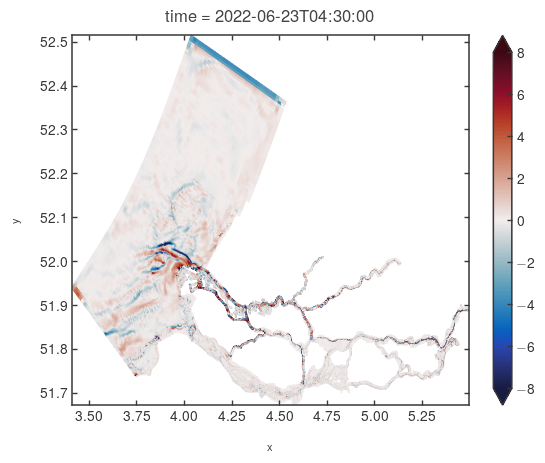

In [178]:
((ucx_grad.isel(mesh2d_nCartesian_coords=0)+ucy_grad.isel(mesh2d_nCartesian_coords=1))/f).isel(mesh2d_nLayers=45, time=5).ugrid.plot(vmin=-8,vmax=8,cmap=cmo.balance)

/home/mgeraeds/.conda/envs/dfm_proc_env/lib/python3.9/site-packages/distributed/client.py:3163: UserWarning: Sending large graph of size 37.21 MiB.
This may cause some slowdown.
Consider scattering data ahead of time and using futures.
  warnings.warn(


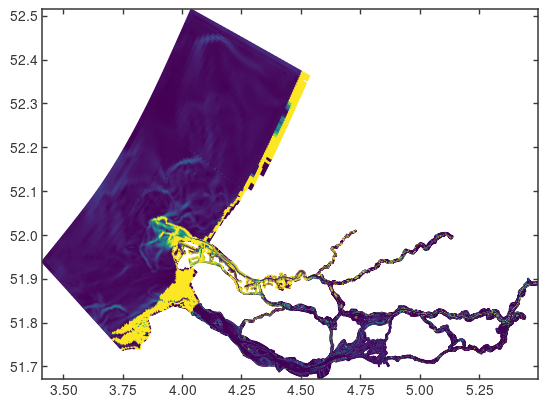

In [188]:
(salinity_gradient*1000).isel(mesh2d_nLayers=45, time=5).ugrid.plot(add_labels=False, add_colorbar=False, vmax=5, zorder=0)